In [153]:
import numpy as np
import torch

np_array = np.array([1.3, 2.2, 3.7, 4.2])

tensor = torch.tensor([1.3, 2.2, 3.7, 4.2])

print(f"Numpy array: {np_array}")
print(f"Tensor: {tensor}")

#

Numpy array: [1.3 2.2 3.7 4.2]
Tensor: tensor([1.3000, 2.2000, 3.7000, 4.2000])


In [154]:
print(tensor.dtype)
print(np_array.dtype)

torch.float32
float64


In [155]:
M1_32 = torch.randn((1000,1000))
M2_32 = torch.randn((1000,1000))

M1_64 = M1_32.double()
M2_64 = M2_32.double()

from timeit import timeit

# Example timing for float64 and float32 matrix multiplication
t64 = timeit(lambda: M1_64 @ M2_64 , number =100)
t32 = timeit(lambda: M1_32 @ M2_32 , number =100)
print(f"Time for matrix multiplication (float64): {t64:.4f}s")
print(f"Time for matrix multiplication (float32): {t32:.4f}s")


Time for matrix multiplication (float64): 4.2729s
Time for matrix multiplication (float32): 1.4221s


In [156]:
M1_32.to('cuda')
M2_32.to('cuda')

t_cuda = timeit(lambda: M1_32 @ M2_32 , number =100)
print(f"Time for matrix multiplication (CUDA): {t_cuda:.4f}s")

Time for matrix multiplication (CUDA): 1.4439s


## Exercise 2



In [157]:
from torch.utils.data import dataset, dataloader, TensorDataset, DataLoader

n = 2048

X = torch.randn(n,1)
epsilon = torch.randn(n,1) * 0.1

y = 5 * X + 3 + epsilon

print(X.shape, y.shape)
print(X[:5], y[:5])  # mostra i primi 5 campioni

torch.Size([2048, 1]) torch.Size([2048, 1])
tensor([[ 0.4787],
        [-0.8699],
        [-1.5372],
        [ 0.3689],
        [ 1.0864]]) tensor([[ 5.3180],
        [-1.1237],
        [-4.6693],
        [ 4.8476],
        [ 8.5654]])


In [158]:
dataset = TensorDataset(X,y)
print(dataset[0])

(tensor([0.4787]), tensor([5.3180]))


In [159]:
trainloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [160]:
for X_batch, y_batch in trainloader:
    print(X_batch.shape, y_batch.shape)
    break

torch.Size([256, 1]) torch.Size([256, 1])


## Exercise 3

In [161]:
import torch.nn as nn

class SimpleLinearModel(nn.Module):
  def __init__(self , input_size , output_size):
    super(SimpleLinearModel , self).__init__ ()
    self.linear = nn.Linear(input_size, output_size)

  def forward(self , x):
    return self.linear(x)



In [162]:
# Instantiate the model
model = SimpleLinearModel(1,1)

input_tensor = X
output = model(input_tensor)
print(output)

tensor([[-0.5824],
        [-0.3401],
        [-0.2203],
        ...,
        [-0.2816],
        [-0.5133],
        [-0.2628]], grad_fn=<AddmmBackward0>)


In [163]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = ('cpu')
print(device)


cuda


In [164]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [165]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

num_epochs = 50
losses , weights , biases = [], [], []

# Move the model to the CUDA device
model.to(device)

model.train()
for epoch in range(num_epochs):
  running_loss = 0.0
  for inputs , labels in trainloader:
    inputs, labels = inputs.to(device), labels.to(device)

    # Zero the parameter gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    # Save the loss, weight, and bias
    losses.append(loss.item())
    weights.append(model.linear.weight.item())
    biases.append(model.linear.bias.item())
    running_loss += loss.item()

  # Print loss every epoch
  print(f"Epoch[{epoch+1}/{num_epochs}] - Loss: {running_loss/len(trainloader):.4f}") # Corrected len(dataloader) to len(trainloader)

Epoch[1/50] - Loss: 34.4611
Epoch[2/50] - Loss: 24.8356
Epoch[3/50] - Loss: 17.9051
Epoch[4/50] - Loss: 12.9075
Epoch[5/50] - Loss: 9.3077
Epoch[6/50] - Loss: 6.7106
Epoch[7/50] - Loss: 4.8395
Epoch[8/50] - Loss: 3.4910
Epoch[9/50] - Loss: 2.5191
Epoch[10/50] - Loss: 1.8187
Epoch[11/50] - Loss: 1.3138
Epoch[12/50] - Loss: 0.9497
Epoch[13/50] - Loss: 0.6873
Epoch[14/50] - Loss: 0.4983
Epoch[15/50] - Loss: 0.3620
Epoch[16/50] - Loss: 0.2637
Epoch[17/50] - Loss: 0.1929
Epoch[18/50] - Loss: 0.1419
Epoch[19/50] - Loss: 0.1051
Epoch[20/50] - Loss: 0.0786
Epoch[21/50] - Loss: 0.0594
Epoch[22/50] - Loss: 0.0457
Epoch[23/50] - Loss: 0.0357
Epoch[24/50] - Loss: 0.0286
Epoch[25/50] - Loss: 0.0234
Epoch[26/50] - Loss: 0.0197
Epoch[27/50] - Loss: 0.0170
Epoch[28/50] - Loss: 0.0151
Epoch[29/50] - Loss: 0.0137
Epoch[30/50] - Loss: 0.0127
Epoch[31/50] - Loss: 0.0120
Epoch[32/50] - Loss: 0.0115
Epoch[33/50] - Loss: 0.0111
Epoch[34/50] - Loss: 0.0108
Epoch[35/50] - Loss: 0.0106
Epoch[36/50] - Loss: 0.01

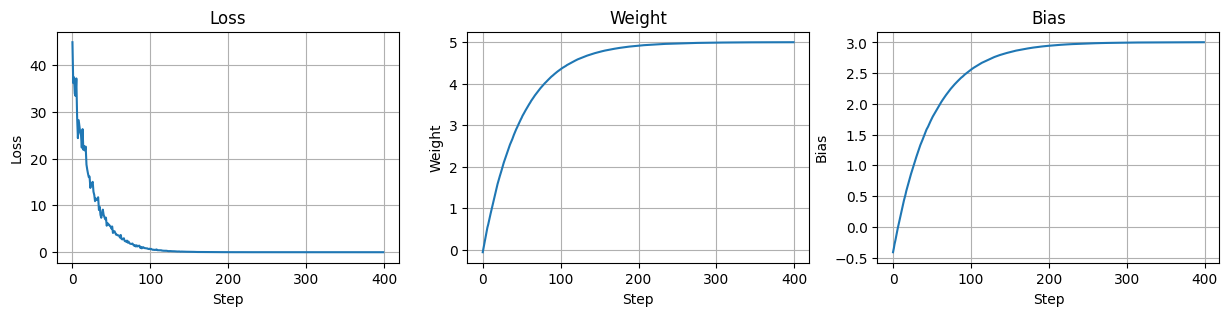

In [166]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

ax[0].plot(losses)
ax[0].set_title('Loss')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('Loss')
ax[0].grid()

ax[1].plot(weights)
ax[1].set_title('Weight')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Weight')
ax[1].grid()

ax[2].plot(biases)
ax[2].set_title('Bias')
ax[2].set_xlabel('Step')
ax[2].set_ylabel('Bias')
ax[2].grid()



In [167]:
from torchvision import datasets , transforms
train_dataset = datasets.MNIST(root="data", train=True , download=True)
test_dataset = datasets.MNIST(root="data", train=False , download=True)

In [168]:
train_dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [169]:
image, label = train_dataset[0]
print(image)
print(label)

<PIL.Image.Image image mode=L size=28x28 at 0x782E1C1917F0>
5


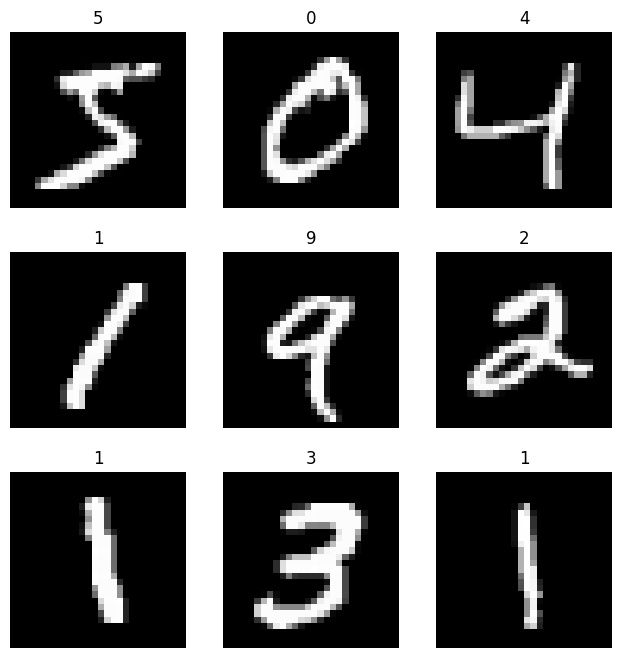

In [173]:
fig, ax = plt.subplots(3, 3, figsize=(8, 8))
plt.subplots_adjust(hspace=0.25, wspace=0.1)

for i in range(3):
  for j in range(3):
    idx = i * 3 + j
    img, label = train_dataset[idx]

    ax[i, j].imshow(img, cmap='gray')
    ax[i, j].set_title(label)
    ax[i, j].axis('off')

In [ ]:
transform = transforms.ToTensor()

train_dataset.transform =
test_dataset.transform =

image, label = train_dataset[0]